
# Solution Key to Assignment on Neural Network

This notebook contains:
- full worked solutions,
- runnable Python code,
- metric calculations,
- training/evaluation examples using `scikit-learn`.

To keep the notebook lightweight and portable, the neural network model uses:
- `MLPClassifier` from `scikit-learn`,
- `LogisticRegression` as a baseline,
- synthetic bioinformatics-style datasets created with `make_classification`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)


## Shared Example Dataset

In [15]:
X, y = make_classification(
    n_samples=500,
    n_features=40,
    n_informative=12,
    n_redundant=8,
    n_clusters_per_class=2,
    class_sep=1.1,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:", np.bincount(y))


X shape: (500, 40)
y shape: (500,)
Class counts: [251 249]


In [16]:
in_file_name = "gene_expression_binary.csv"
df = pd.read_csv(in_file_name)

print(df.shape)
print(df.head())

(180, 301)
     Gene_1    Gene_2    Gene_3    Gene_4    Gene_5    Gene_6    Gene_7  \
0  0.165362  1.052481  0.250059  0.647174  0.999504  7.399953 -0.139929   
1 -0.780324 -0.108025  0.716442  0.435419 -0.609848 -0.242195 -0.439404   
2  0.231719 -1.680229 -0.565501 -0.042879 -0.494839  4.032141  0.764033   
3  0.491246  0.388259 -1.901445  1.927810  0.204609  4.682180  0.168620   
4 -2.448968  2.164372 -0.509130 -0.013008  1.309486 -2.768720 -0.479120   

     Gene_8    Gene_9   Gene_10  ...  Gene_292  Gene_293   Gene_294  Gene_295  \
0 -0.825100 -1.731810  0.490245  ...  1.835600  1.515755  -0.091484 -0.932527   
1  0.193077  2.019842  1.014541  ...  1.146299  0.978062 -12.977023 -0.012661   
2 -1.069174  0.868155  1.517235  ...  0.307717 -1.219386  17.469884 -1.112189   
3 -0.259217 -0.272536 -0.005169  ...  0.628027  0.454545  -6.172395 -1.510199   
4  0.468360 -1.277465 -0.972258  ...  1.002873 -0.736546  -0.641376  0.128546   

   Gene_296  Gene_297  Gene_298  Gene_299  Gene_300

In [17]:
X = df.drop(columns=["disease_label"]).values
feature_names = df.drop(columns=["disease_label"]).columns.tolist()

y = df["disease_label"].values


## Problem 1 — Data Preparation for a Neural Network

### Worked solution
We split data into:
- **training set** to fit model parameters,
- **validation set** to tune settings and compare choices,
- **test set** to estimate final generalization.

A 60/20/20 split can be created in two stages.


In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (108, 300) (108,)
Validation shape: (36, 300) (36,)
Test shape: (36, 300) (36,)



Feature scaling matters because neural networks usually train more stably when features are on similar scales.

Fit the scaler on the **training set only**, then apply it to validation and test data.


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training means (first 3 variables):", X_train_scaled.mean(axis=0)[:3].round(4))
print("Scaled training stds (first 3 variables):", X_train_scaled.std(axis=0)[:3].round(4))


Scaled training means (first 3 variables): [0. 0. 0.]
Scaled training stds (first 3 variables): [1. 1. 1.]



## Problem 2 — Build a Simple Neural Network Classifier in Python

Requested architecture:
- 40 input features,
- one hidden layer with 16 neurons,
- ReLU hidden activation,
- binary output.

In `MLPClassifier`, binary probabilities are obtained with `predict_proba`.


In [21]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

val_proba = mlp.predict_proba(X_val_scaled)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

print("First 10 validation probabilities:", np.round(val_proba[:10], 4))
print("First 10 validation predictions:", val_pred[:10])
print("Validation accuracy:", round(accuracy_score(y_val, val_pred), 4))


First 10 validation probabilities: [0.0417 0.4522 0.0689 0.2928 0.0966 0.0236 0.656  0.1142 0.9584 0.3735]
First 10 validation predictions: [0 0 0 0 0 0 1 0 1 0]
Validation accuracy: 0.8056



**Predicted probability** is a continuous confidence score from 0 to 1.  
**Predicted class** is obtained by thresholding that probability, often at 0.5.



## Problem 3 — Monitor Training Behavior

If:
- training loss keeps decreasing,
- validation loss decreases at first,
- then validation loss increases,

that pattern suggests **overfitting**.

Early stopping halts training when validation performance stops improving.


Iterations actually used: 29
Final training loss: 0.1852


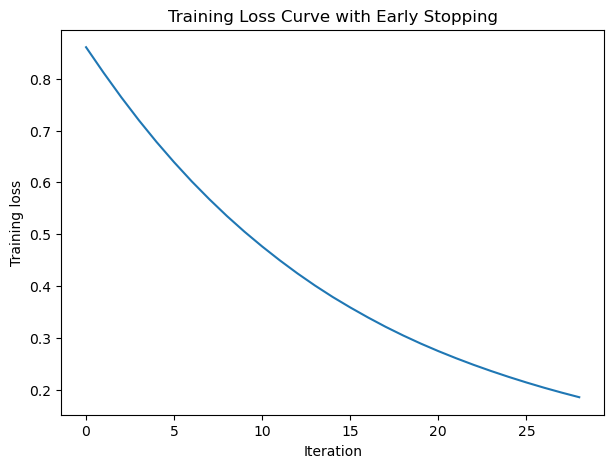

In [7]:

mlp_es = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=15,
    random_state=42
)

mlp_es.fit(X_train_scaled, y_train)

print("Iterations actually used:", mlp_es.n_iter_)
print("Final training loss:", round(mlp_es.loss_, 4))

plt.plot(mlp_es.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("Training Loss Curve with Early Stopping")
plt.show()



Validation loss is often more informative than training accuracy because training accuracy can improve even while the model is getting worse at generalizing.



## Problem 4 — Accuracy Is Not Enough

Suppose:
- 95% of test samples are negative,
- 5% are positive,
- the model predicts every sample as negative.

This model is not useful because it never detects the positive class.


In [8]:

y_imbal = np.array([0]*95 + [1]*5)
y_pred_all_negative = np.zeros_like(y_imbal)

acc = accuracy_score(y_imbal, y_pred_all_negative)
prec = precision_score(y_imbal, y_pred_all_negative, zero_division=0)
rec = recall_score(y_imbal, y_pred_all_negative, zero_division=0)
f1 = f1_score(y_imbal, y_pred_all_negative, zero_division=0)
cm = confusion_matrix(y_imbal, y_pred_all_negative)

print("Confusion matrix:")
print(cm)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)


Confusion matrix:
[[95  0]
 [ 5  0]]
Accuracy: 0.95
Precision: 0.0
Recall: 0.0
F1: 0.0



Even with 95% accuracy, recall for the positive class is 0.  
In many biomedical applications, false negatives can be especially harmful because real cases are missed.



## Problem 5 — Confusion Matrix Interpretation

Given:
\[
\begin{bmatrix}
82 & 8 \\
5 & 15
\end{bmatrix}
\]

So:
- TN = 82
- FP = 8
- FN = 5
- TP = 15


In [ ]:

TN, FP, FN, TP = 82, 8, 5, 15

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
f1 = 2 * precision * recall / (precision + recall)

pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1"],
    "Value": [accuracy, precision, recall, specificity, f1]
})



Here the model is **more specific than sensitive**, because specificity is higher than recall.



## Problem 6 — ROC Curve and AUC

The ROC curve plots:
- false positive rate on the x-axis,
- true positive rate on the y-axis,

across thresholds.

AUC summarizes ranking performance across all thresholds.


Test ROC-AUC: 0.7747


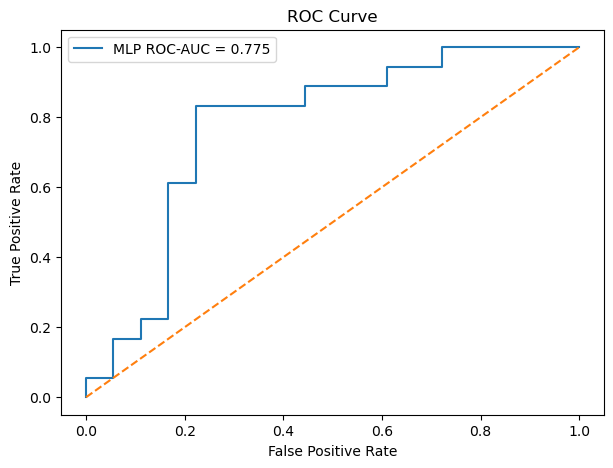

In [9]:

test_proba = mlp.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, test_proba)
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

print("Test ROC-AUC:", round(roc_auc, 4))

plt.plot(fpr, tpr, label=f"MLP ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



ROC-AUC uses probabilities rather than fixed class labels because the curve is generated by sweeping through many thresholds.

On highly imbalanced data, ROC-AUC can sometimes appear strong even when positive-class precision is poor.



## Problem 7 — Precision-Recall Curve

The PR curve plots:
- recall on the x-axis,
- precision on the y-axis.

It is often more informative than ROC in rare-event settings.


Average Precision: 0.7246


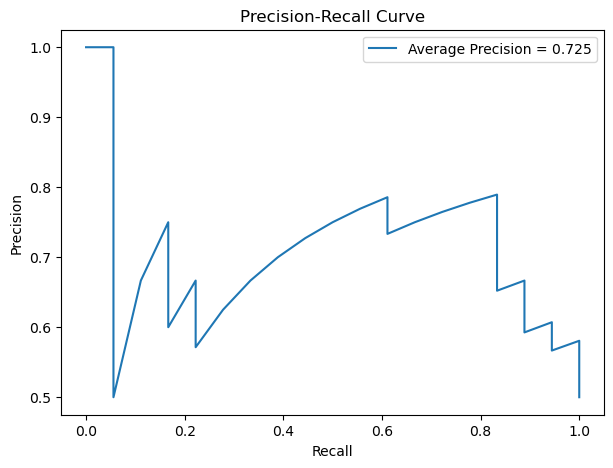

In [10]:

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)

print("Average Precision:", round(ap, 4))

plt.plot(recall_vals, precision_vals, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()



If recall is high but precision is low, the model finds many true positives but also produces many false alarms.



## Problem 8 — Threshold Tuning

If the goal is to reduce false negatives, the threshold should usually be **decreased**.

That tends to increase recall but reduce precision.


In [11]:

threshold_results = []
for thr in [0.3, 0.5, 0.7]:
    pred_thr = (test_proba >= thr).astype(int)
    threshold_results.append({
        "Threshold": thr,
        "Precision": precision_score(y_test, pred_thr, zero_division=0),
        "Recall": recall_score(y_test, pred_thr, zero_division=0),
        "F1": f1_score(y_test, pred_thr, zero_division=0),
        "Accuracy": accuracy_score(y_test, pred_thr)
    })

pd.DataFrame(threshold_results)


,Threshold,Precision,Recall,F1,Accuracy
0,0.3,0.789474,0.833333,0.810811,0.805556
1,0.5,0.769231,0.555556,0.645161,0.694444
2,0.7,0.625000,0.277778,0.384615,0.555556



## Problem 9 — Multiclass Neural Network Evaluation

For 4 classes:
- conceptually, the output activation is **softmax**,
- the loss is **multiclass cross-entropy**.

`MLPClassifier` handles multiclass classification automatically.


In [12]:

X_mc, y_mc = make_classification(
    n_samples=700,
    n_features=30,
    n_informative=12,
    n_redundant=6,
    n_classes=4,
    n_clusters_per_class=1,
    random_state=42
)

X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.25, stratify=y_mc, random_state=42
)

mc_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42))
])

mc_pipe.fit(X_mc_train, y_mc_train)
y_mc_pred = mc_pipe.predict(X_mc_test)

print("Multiclass accuracy:", round(accuracy_score(y_mc_test, y_mc_pred), 4))
print("Macro F1:", round(f1_score(y_mc_test, y_mc_pred, average="macro"), 4))
print("Weighted F1:", round(f1_score(y_mc_test, y_mc_pred, average="weighted"), 4))
print("Confusion matrix:")
print(confusion_matrix(y_mc_test, y_mc_pred))


Multiclass accuracy: 0.8514
Macro F1: 0.8498
Weighted F1: 0.8498
Confusion matrix:
[[39  1  2  2]
 [ 1 42  1  0]
 [ 3  0 35  5]
 [ 2  7  2 33]]



- **Macro F1** treats all classes equally.
- **Weighted F1** weights classes by frequency.

A confusion matrix is especially useful in multiclass tasks because it shows which classes are confused with each other.



## Problem 10 — Overfitting in Python Experiments

Given:
- Model A: training accuracy 99%, validation accuracy 68%
- Model B: training accuracy 87%, validation accuracy 84%

**Model B** is likely generalizing better.  
**Model A** is likely overfitting.

Ways to reduce overfitting:
1. use a smaller network,
2. strengthen regularization,
3. use early stopping,
4. collect more data,
5. improve feature selection.



## Problem 11 — Mini-Batch Training and Epochs

If there are 1,000 training samples and batch size is 50, then there are:

\[
1000/50 = 20
\]

mini-batches in one epoch.

An **epoch** means one full pass through the training set.

Mini-batch gradient descent is usually preferred because it balances efficiency and gradient quality.



## Problem 12 — Learning Curves

Scenario A:
- training accuracy rises,
- validation accuracy rises and stays close.

Interpretation: good learning and good generalization.

Scenario B:
- training accuracy approaches 100%,
- validation accuracy peaks then declines.

Interpretation: overfitting.


In [ ]:

epochs = np.arange(1, 21)
train_curve_A = np.linspace(0.60, 0.88, 20)
val_curve_A = np.linspace(0.58, 0.85, 20)

train_curve_B = np.linspace(0.60, 0.99, 20)
val_curve_B = np.array([0.55, 0.60, 0.66, 0.70, 0.73, 0.75, 0.76, 0.76, 0.75, 0.74,
                        0.73, 0.72, 0.71, 0.70, 0.69, 0.69, 0.68, 0.68, 0.67, 0.67])

plt.plot(epochs, train_curve_A, label="Train A")
plt.plot(epochs, val_curve_A, label="Validation A")
plt.plot(epochs, train_curve_B, label="Train B")
plt.plot(epochs, val_curve_B, label="Validation B")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Illustrative Learning Curves")
plt.legend()
plt.show()



## Problem 13 — Compare Neural Network with Logistic Regression

Comparing against a simple baseline is important because extra model complexity should be justified by better performance.


In [13]:

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42))
])

logreg_pipe.fit(X_train, y_train)
mlp_pipe.fit(X_train, y_train)

logreg_proba = logreg_pipe.predict_proba(X_test)[:, 1]
mlp_proba = mlp_pipe.predict_proba(X_test)[:, 1]

logreg_pred = (logreg_proba >= 0.5).astype(int)
mlp_pred = (mlp_proba >= 0.5).astype(int)

pd.DataFrame({
    "Model": ["Logistic Regression", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, logreg_pred),
        accuracy_score(y_test, mlp_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, logreg_proba),
        roc_auc_score(y_test, mlp_proba)
    ],
    "F1": [
        f1_score(y_test, logreg_pred),
        f1_score(y_test, mlp_pred)
    ]
})


,Model,Accuracy,ROC_AUC,F1
0,Logistic Regression,0.638889,0.771605,0.606061
1,Neural Network,0.694444,0.774691,0.645161



Logistic regression may outperform a neural network when:
- dataset size is small,
- the signal is mostly linear,
- the neural network is too flexible and overfits.

In biomedical research, a simpler interpretable model may be preferable when performance is similar.



## Problem 14 — Debugging a Poor Neural Network Model

Suppose:
- training accuracy stays near 50%,
- validation accuracy stays near 50%,
- loss barely changes.

Possible reasons:
1. learning rate too small,
2. learning rate too large,
3. missing or incorrect feature scaling,
4. incorrect labels,
5. insufficient model capacity,
6. coding bugs,
7. severe class imbalance,
8. train/label misalignment.

For each suspected issue:
- inspect the data,
- verify label integrity,
- review preprocessing,
- compare against a simple baseline,
- try different hyperparameters.



## Problem 15 — End-to-End Python Coding Task

This example:
1. splits a dataset,
2. standardizes features,
3. trains a neural network,
4. predicts probabilities,
5. converts probabilities to class labels,
6. computes metrics,
7. plots ROC and PR curves.


In [ ]:

X2, y2 = make_classification(
    n_samples=600,
    n_features=25,
    n_informative=10,
    n_redundant=5,
    weights=[0.8, 0.2],
    random_state=123
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, stratify=y2, random_state=123
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(20,), max_iter=500, random_state=123))
])

pipe.fit(X2_train, y2_train)

y2_proba = pipe.predict_proba(X2_test)[:, 1]
y2_pred = (y2_proba >= 0.5).astype(int)

acc = accuracy_score(y2_test, y2_pred)
cm = confusion_matrix(y2_test, y2_pred)
prec = precision_score(y2_test, y2_pred, zero_division=0)
rec = recall_score(y2_test, y2_pred, zero_division=0)
f1 = f1_score(y2_test, y2_pred, zero_division=0)
auc = roc_auc_score(y2_test, y2_proba)

print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))
print("Confusion matrix:")
print(cm)

fpr, tpr, _ = roc_curve(y2_test, y2_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y2_test, y2_proba)
ap = average_precision_score(y2_test, y2_proba)

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.plot(rec_curve, prec_curve, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()



For highly imbalanced data, **precision, recall, F1, and PR-AUC** are usually more informative than plain accuracy.



## Optional Challenge — Class Imbalance with Class Weights

`MLPClassifier` does not directly expose class weights, so this demonstration uses logistic regression to illustrate the idea.


In [ ]:

X_im, y_im = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.93, 0.07],
    random_state=7
)

X_im_train, X_im_test, y_im_train, y_im_test = train_test_split(
    X_im, y_im, test_size=0.25, stratify=y_im, random_state=7
)

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=7))
])

weighted = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=7))
])

baseline.fit(X_im_train, y_im_train)
weighted.fit(X_im_train, y_im_train)

for name, model in [("Baseline", baseline), ("Balanced", weighted)]:
    proba = model.predict_proba(X_im_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print(f"\n{name}")
    print("Precision:", round(precision_score(y_im_test, pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_im_test, pred, zero_division=0), 4))
    print("F1:", round(f1_score(y_im_test, pred, zero_division=0), 4))
    print("ROC-AUC:", round(roc_auc_score(y_im_test, proba), 4))



## Summary

This notebook shows how to:
- prepare data correctly,
- train neural networks in Python,
- evaluate them with multiple metrics,
- interpret ROC and PR curves,
- tune thresholds,
- compare against logistic regression,
- diagnose overfitting and underfitting.
